## 最終課題：公共交通機関における「時間」と「運賃」のトレードオフ分析

In [15]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib
from scipy.optimize import curve_fit
import os

def get_comparison_data():
    """DBからクエリを発行してデータを取得する """
    # scraper.pyと同じディレクトリにあるDBを参照
    db_path = "transit_data.db"
    if not os.path.exists(db_path):
        raise FileNotFoundError(f"{db_path}が見つかりません。先にscraper.pyを実行してください。")

    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query("SELECT * FROM travel_results", conn)
    conn.close()

    results = []
    for dest in df['destination'].unique():
        target = df[df['destination'] == dest]
        # 最速と最安の比較
        fastest = target.loc[target['travel_time'].idxmin()]
        cheapest = target.loc[target['fare'].idxmin()]
        
        t_diff = cheapest['travel_time'] - fastest['travel_time']
        f_diff = fastest['fare'] - cheapest['fare']
        
        if t_diff > 0:
            results.append({
                'destination': dest,
                'base_time': cheapest['travel_time'],
                'cost_per_min': f_diff / t_diff
            })
    return pd.DataFrame(results)

df_analysis = get_comparison_data()

## 所要時間と1分あたりの短縮コストの関係

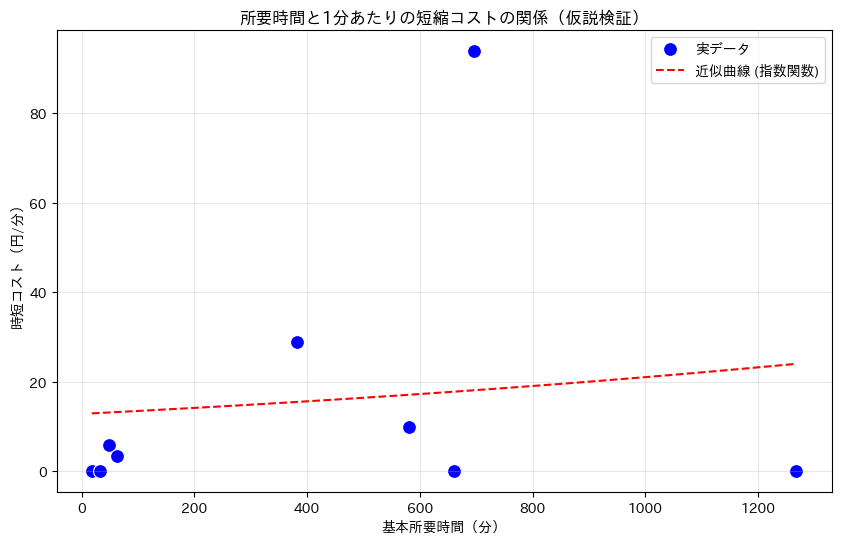

推定モデル: y = 12.8477 * exp(0.0005 * x)


In [18]:
def plot_hypothesis_verification(df):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='base_time', y='cost_per_min', s=100, color='blue', label='実データ')

    # 指数関数の近似
    def func(x, a, b):
        return a * np.exp(b * x)

    # 近似曲線のパラメータ推定
    popt, _ = curve_fit(func, df['base_time'], df['cost_per_min'], p0=(1, 0.005))
    
    x_line = np.linspace(df['base_time'].min(), df['base_time'].max(), 100)
    plt.plot(x_line, func(x_line, *popt), 'r--', label='近似曲線 (指数関数)')

    plt.title("所要時間と1分あたりの短縮コストの関係（仮説検証）")
    plt.xlabel("基本所要時間（分）")
    plt.ylabel("時短コスト（円/分）")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"推定モデル: y = {popt[0]:.4f} * exp({popt[1]:.4f} * x)")

plot_hypothesis_verification(df_analysis)

## 1分を短縮するための追加コスト

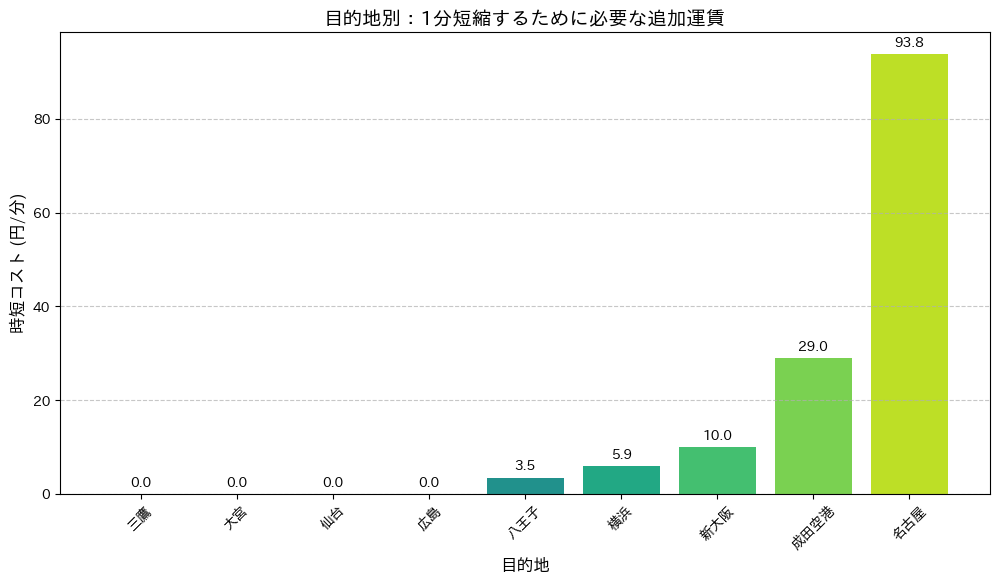

In [21]:
def plot_cost_ranking(df):
    # 時短コストが低い順に並び替え
    df_sorted = df.sort_values('cost_per_min')

    plt.figure(figsize=(12, 6))
    colors = sns.color_palette("viridis", len(df_sorted))
    
    # 棒グラフの描画
    bars = plt.bar(df_sorted['destination'], df_sorted['cost_per_min'], color=colors)
    
    plt.title("目的地別：1分短縮するために必要な追加運賃", fontsize=14)
    plt.xlabel("目的地", fontsize=12)
    plt.ylabel("時短コスト (円/分)", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # 数値を棒の上に表示
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}', ha='center', va='bottom')

    plt.show()

plot_cost_ranking(df_analysis)

## 「所要時間の短縮幅」と「追加運賃」の相関比較

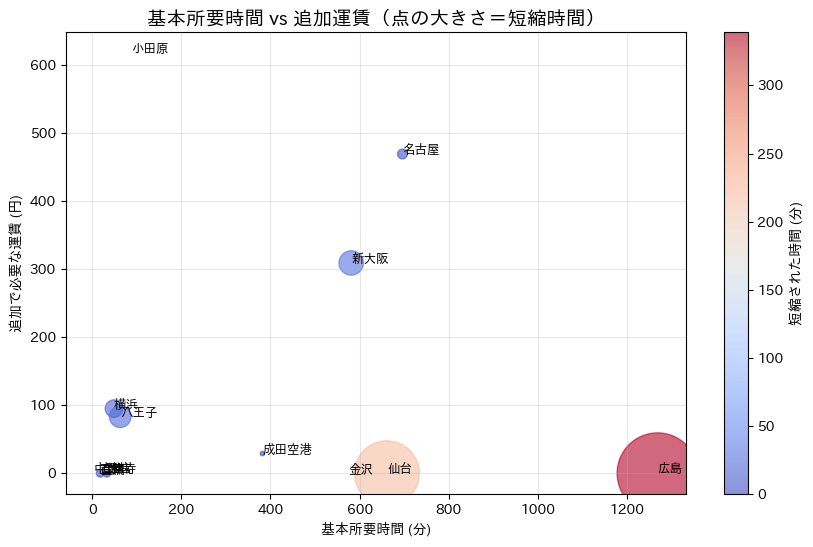

In [22]:
def plot_diff_analysis():
    conn = sqlite3.connect("transit_data.db")
    df = pd.read_sql_query("SELECT * FROM travel_results", conn)
    conn.close()

    diff_data = []
    for dest in df['destination'].unique():
        target = df[df['destination'] == dest]
        fastest = target.loc[target['travel_time'].idxmin()]
        cheapest = target.loc[target['fare'].idxmin()]
        
        diff_data.append({
            'destination': dest,
            'time_saved': cheapest['travel_time'] - fastest['travel_time'],
            'extra_fare': fastest['fare'] - cheapest['fare'],
            'base_time': cheapest['travel_time']
        })
    
    df_diff = pd.DataFrame(diff_data)

    plt.figure(figsize=(10, 6))
    # バブルチャート（点の大きさを時間の短縮幅にする）
    scatter = plt.scatter(df_diff['base_time'], df_diff['extra_fare'], 
                        s=df_diff['time_saved']*10, alpha=0.6, c=df_diff['time_saved'], cmap='coolwarm')
    
    plt.colorbar(scatter, label='短縮された時間 (分)')
    plt.title("基本所要時間 vs 追加運賃（点の大きさ＝短縮時間）", fontsize=14)
    plt.xlabel("基本所要時間 (分)")
    plt.ylabel("追加で必要な運賃 (円)")
    plt.grid(True, alpha=0.3)
    
    for i, txt in enumerate(df_diff['destination']):
        plt.annotate(txt, (df_diff['base_time'][i], df_diff['extra_fare'][i]), fontsize=9)

    plt.show()

plot_diff_analysis()